<a href="https://colab.research.google.com/github/debha-dev/nithub-ml-track/blob/week2-pandas/Life_Expectancy_(WHO)_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project: Life Expectancy (WHO)
## Name: Itulua Cheluh
## Table of Contents
<ul>
<li><a href="#intro">Introduction</a></li>
<li><a href="#wrangling">Data Wrangling</a></li>
<li><a href="#eda">Exploratory Data Analysis</a></li>
<li><a href="#conclusions">Conclusions</a></li>
</ul>

<a id='intro'></a>
## Section I: Introduction

**Dataset**: [ Life Expectancy (WHO)](https://www.kaggle.com/datasets/kumarajarshi/life-expectancy-who)

**Description**: This dataset contains health-related and socio-economic statistics from the World Health Organization (WHO) and United Nations data, covering the years 2000 to 2015. It includes data from over 190 countries and is useful for exploring factors that influence life expectancy, such as income, education, healthcare access, and immunization.

**Columns Description**
- **`Country`**:Name of the country.
- **`Year`**:The year of the recorded data (from 2000 to 2015).
- **`Status`**: Whether the country is a developing or developed country.
- **`Life expectancy`**: Average life expectancy at birth in years.
- **`Adult Mortality`**:Probability of dying between 15 and 60 years per 1000 population.
- **`infant deaths`**: Number of infant deaths per 1000 births.

- **`Alcohol`**: Per capita alcohol consumption (in litres) for ages 15+.

- **`percentage expenditure`**: Expenditure on health as a percentage of GDP.

- **`Hepatitis B`**: Percentage of 1-year-old children immunized against Hepatitis B.

- **`Measles`**: Number of reported cases per 1000 population.

- **`BMI`**: Average Body Mass Index of the population.

- **`under-five deaths`**: Number of deaths under age five per 1000 live births.

- **`Polio`**: Percentage of 1-year-old children immunized against polio.

- **`Total expenditure`**: Total health expenditure as percentage of GDP.

- **`Diphtheria`**: Percentage of 1-year-old children immunized against Diphtheria.

- **`HIV/AIDS`**: Deaths per 1000 live births due to HIV/AIDS (ages 0–4).

- **`GDP`**: Gross Domestic Product per capita (USD).

- **`Population`**: Population of the country.

- **`thinness 1-19 years`**: Prevalence of thinness among children and adolescents (1–19 years).

- **`thinness 5-9 years`**: Prevalence of thinness among children (5–9 years).

- **`Income composition of resources`**: Human development index in terms of income.

- **`Schooling`**: Average number of years of schooling for people aged 25 or older.



***We will be investigating the dataset to uncover the following:***
1. What factors are most associated with increased life expectancy across countries and years?

2. How do economic indicators and immunization efforts relate to public health outcomes like life expectancy or child mortality?

**Research Areas**
1. `Target Variable (Life expectancy)`:
We'll explore how life expectancy varies based on a combination of factors such as GDP, healthcare expenditure, education level, disease rates, and immunization coverage.

2. `Univariate Analysis`:
**Examine individual features to understand their distribution, such as:**

1. Distribution of life expectancy across countries and years

2. Distribution of adult/infant/under-five mortality rates

3. Common values for health spending, schooling, alcohol use, etc.

Sample Questions:

- What is the average life expectancy in developed vs. developing countries?

- How does alcohol consumption vary across regions?

- Which countries have the highest and lowest health expenditures?

3. `Multivariate Analysis`:
Investigate the relationships between multiple features:

1. Correlation between GDP and Life expectancy

2. How does Schooling relate to Infant deaths or Life expectancy?

3. Does higher immunization coverage (e.g., Polio, Hepatitis B) link with lower child mortality?

**LIMITATIONS**
Missing values: Several columns contain missing data, especially in earlier years or certain countries.

Skewed data: Outliers in GDP, population, or disease cases could distort average values.

No causality: The dataset shows correlation, not causation. External policy, conflict, or environmental factors are not included.

Data age: The dataset ends in 2015, and recent global health events like COVID-19 are not reflected.

In [2]:
# importing Required library

import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
%matplotlib inline

In [3]:
# To import the file from kaggle to google collab
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kumarajarshi/life-expectancy-who")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/life-expectancy-who


In [4]:
os.listdir(path) # To print out the files in path

['Life Expectancy Data.csv']

In [5]:
df = pd.read_csv(os.path.join(path, "Life Expectancy Data.csv")) #To read the content of Life Expectancy Data.csv to df
df.head(60)

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
5,Afghanistan,2010,Developing,58.8,279.0,74,0.01,79.679367,66.0,1989,...,66.0,9.20,66.0,0.1,553.328940,2883167.0,18.4,18.4,0.448,9.2
6,Afghanistan,2009,Developing,58.6,281.0,77,0.01,56.762217,63.0,2861,...,63.0,9.42,63.0,0.1,445.893298,284331.0,18.6,18.7,0.434,8.9
7,Afghanistan,2008,Developing,58.1,287.0,80,0.03,25.873925,64.0,1599,...,64.0,8.33,64.0,0.1,373.361116,2729431.0,18.8,18.9,0.433,8.7
8,Afghanistan,2007,Developing,57.5,295.0,82,0.02,10.910156,63.0,1141,...,63.0,6.73,63.0,0.1,369.835796,26616792.0,19.0,19.1,0.415,8.4
9,Afghanistan,2006,Developing,57.3,295.0,84,0.03,17.171518,64.0,1990,...,58.0,7.43,58.0,0.1,272.563770,2589345.0,19.2,19.3,0.405,8.1


In [6]:
df.columns = df.columns.str.strip().str.replace(" ", "_")

In [7]:
df.drop_duplicates(inplace=True)
df.head(60)

,Country,Year,Status,Life_expectancy,Adult_Mortality,infant_deaths,Alcohol,percentage_expenditure,Hepatitis_B,Measles,...,Polio,Total_expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness__1-19_years,thinness_5-9_years,Income_composition_of_resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
5,Afghanistan,2010,Developing,58.8,279.0,74,0.01,79.679367,66.0,1989,...,66.0,9.20,66.0,0.1,553.328940,2883167.0,18.4,18.4,0.448,9.2
6,Afghanistan,2009,Developing,58.6,281.0,77,0.01,56.762217,63.0,2861,...,63.0,9.42,63.0,0.1,445.893298,284331.0,18.6,18.7,0.434,8.9
7,Afghanistan,2008,Developing,58.1,287.0,80,0.03,25.873925,64.0,1599,...,64.0,8.33,64.0,0.1,373.361116,2729431.0,18.8,18.9,0.433,8.7
8,Afghanistan,2007,Developing,57.5,295.0,82,0.02,10.910156,63.0,1141,...,63.0,6.73,63.0,0.1,369.835796,26616792.0,19.0,19.1,0.415,8.4
9,Afghanistan,2006,Developing,57.3,295.0,84,0.03,17.171518,64.0,1990,...,58.0,7.43,58.0,0.1,272.563770,2589345.0,19.2,19.3,0.405,8.1


In [8]:
for column in df.columns:
    mode_value = df[column].mode()[0]
    df[column].fillna(mode_value, inplace=True)

# Confirm no missing values
print(df.isnull().sum())

Country                            0
Year                               0
Status                             0
Life_expectancy                    0
Adult_Mortality                    0
infant_deaths                      0
Alcohol                            0
percentage_expenditure             0
Hepatitis_B                        0
Measles                            0
BMI                                0
under-five_deaths                  0
Polio                              0
Total_expenditure                  0
Diphtheria                         0
HIV/AIDS                           0
GDP                                0
Population                         0
thinness__1-19_years               0
thinness_5-9_years                 0
Income_composition_of_resources    0
Schooling                          0
dtype: int64


/tmp/ipython-input-8-3176902520.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(mode_value, inplace=True)
/tmp/ipython-input-8-3176902520.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

In [9]:
df.head(60)

,Country,Year,Status,Life_expectancy,Adult_Mortality,infant_deaths,Alcohol,percentage_expenditure,Hepatitis_B,Measles,...,Polio,Total_expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness__1-19_years,thinness_5-9_years,Income_composition_of_resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
5,Afghanistan,2010,Developing,58.8,279.0,74,0.01,79.679367,66.0,1989,...,66.0,9.20,66.0,0.1,553.328940,2883167.0,18.4,18.4,0.448,9.2
6,Afghanistan,2009,Developing,58.6,281.0,77,0.01,56.762217,63.0,2861,...,63.0,9.42,63.0,0.1,445.893298,284331.0,18.6,18.7,0.434,8.9
7,Afghanistan,2008,Developing,58.1,287.0,80,0.03,25.873925,64.0,1599,...,64.0,8.33,64.0,0.1,373.361116,2729431.0,18.8,18.9,0.433,8.7
8,Afghanistan,2007,Developing,57.5,295.0,82,0.02,10.910156,63.0,1141,...,63.0,6.73,63.0,0.1,369.835796,26616792.0,19.0,19.1,0.415,8.4
9,Afghanistan,2006,Developing,57.3,295.0,84,0.03,17.171518,64.0,1990,...,58.0,7.43,58.0,0.1,272.563770,2589345.0,19.2,19.3,0.405,8.1


In [10]:
# Check data types
print(df.dtypes)

Country                             object
Year                                 int64
Status                              object
Life_expectancy                    float64
Adult_Mortality                    float64
infant_deaths                        int64
Alcohol                            float64
percentage_expenditure             float64
Hepatitis_B                        float64
Measles                              int64
BMI                                float64
under-five_deaths                    int64
Polio                              float64
Total_expenditure                  float64
Diphtheria                         float64
HIV/AIDS                           float64
GDP                                float64
Population                         float64
thinness__1-19_years               float64
thinness_5-9_years                 float64
Income_composition_of_resources    float64
Schooling                          float64
dtype: object


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life_expectancy                  2938 non-null   float64
 4   Adult_Mortality                  2938 non-null   float64
 5   infant_deaths                    2938 non-null   int64  
 6   Alcohol                          2938 non-null   float64
 7   percentage_expenditure           2938 non-null   float64
 8   Hepatitis_B                      2938 non-null   float64
 9   Measles                          2938 non-null   int64  
 10  BMI                              2938 non-null   float64
 11  under-five_deaths                2938 non-null   int64  
 12  Polio               

In [12]:
df.describe()

,Year,Life_expectancy,Adult_Mortality,infant_deaths,Alcohol,percentage_expenditure,Hepatitis_B,Measles,BMI,under-five_deaths,Polio,Total_expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness__1-19_years,thinness_5-9_years,Income_composition_of_resources,Schooling
count,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2.938000e+03,2938.000000,2938.000000,2938.00000,2938.000000
mean,2007.518720,69.237781,164.276378,30.303948,4.299588,738.251295,84.339687,2419.592240,38.554765,42.035739,82.656569,5.835252,82.431926,1.742103,6342.347799,9.923249e+06,4.795269,4.824370,0.59188,12.043125
std,4.613841,9.510183,124.399126,117.926501,4.079052,1987.914858,23.664672,11467.272489,20.044238,160.445548,23.389352,2.426626,23.677846,5.077785,13409.380598,5.407584e+07,4.413688,4.502781,0.25114,3.270983
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.370000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.00000,0.000000
25%,2004.000000,63.200000,73.000000,0.000000,0.470000,4.685343,82.000000,0.000000,19.400000,0.000000,78.000000,4.370000,78.000000,0.100000,190.174435,5.874250e+03,1.500000,1.500000,0.46500,10.300000
50%,2008.000000,72.100000,144.000000,3.000000,3.130000,64.912906,95.000000,17.000000,43.900000,4.000000,93.000000,5.540000,93.000000,0.100000,1171.983435,5.393575e+05,3.300000,3.300000,0.66200,12.500000
75%,2012.000000,75.600000,227.000000,22.000000,7.390000,441.534144,99.000000,360.250000,56.475000,28.000000,97.000000,7.330000,97.000000,0.800000,4779.405190,4.584371e+06,7.100000,7.200000,0.77200,14.100000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.600000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.94800,20.700000


In [13]:
selected_cols = [
    'Country', 'Year', 'Status', 'Life_expectancy', 'Adult_Mortality', 'infant_deaths',
    'Hepatitis_B', 'Polio', 'BMI', 'GDP', 'Schooling',
    'Total_expenditure', 'Alcohol', 'under-five_deaths'
] # the columns we would be using

df = df[selected_cols]
df

,Country,Year,Status,Life_expectancy,Adult_Mortality,infant_deaths,Hepatitis_B,Polio,BMI,GDP,Schooling,Total_expenditure,Alcohol,under-five_deaths
0,Afghanistan,2015,Developing,65.0,263.0,62,65.0,6.0,19.1,584.259210,10.1,8.16,0.01,83
1,Afghanistan,2014,Developing,59.9,271.0,64,62.0,58.0,18.6,612.696514,10.0,8.18,0.01,86
2,Afghanistan,2013,Developing,59.9,268.0,66,64.0,62.0,18.1,631.744976,9.9,8.13,0.01,89
3,Afghanistan,2012,Developing,59.5,272.0,69,67.0,67.0,17.6,669.959000,9.8,8.52,0.01,93
4,Afghanistan,2011,Developing,59.2,275.0,71,68.0,68.0,17.2,63.537231,9.5,7.87,0.01,97
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,Zimbabwe,2004,Developing,44.3,723.0,27,68.0,67.0,27.1,454.366654,9.2,7.13,4.36,42
2934,Zimbabwe,2003,Developing,44.5,715.0,26,7.0,7.0,26.7,453.351155,9.5,6.52,4.06,41
2935,Zimbabwe,2002,Developing,44.8,73.0,25,73.0,73.0,26.3,57.348340,10.0,6.53,4.43,40
2936,Zimbabwe,2001,Developing,45.3,686.0,25,76.0,76.0,25.9,548.587312,9.8,6.16,1.72,39


**UNIVARIATE ANALYSIS**

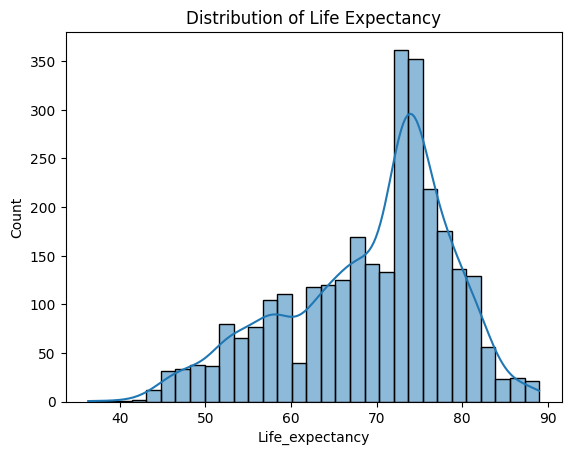

In [14]:
# Life expectancy distribution
sns.histplot(df['Life_expectancy'], kde=True)
plt.title("Distribution of Life Expectancy")
plt.show()

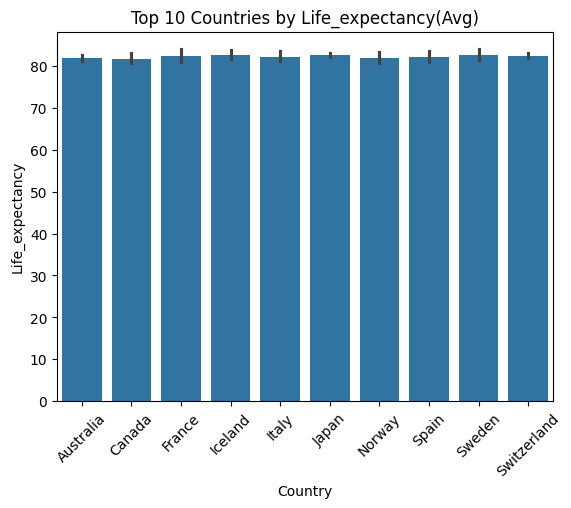

In [15]:
#To get the top countries by Life expectancy
top10_Life_expectancy = df.groupby('Country')['Life_expectancy'].mean().sort_values(ascending=False).head(10)
df_top10 = df[df['Country'].isin(top10_Life_expectancy.index)]

sns.barplot(x='Country', y='Life_expectancy', data=df_top10)
plt.title("Top 10 Countries by Life_expectancy(Avg)")
plt.xticks(rotation=45)
plt.show()


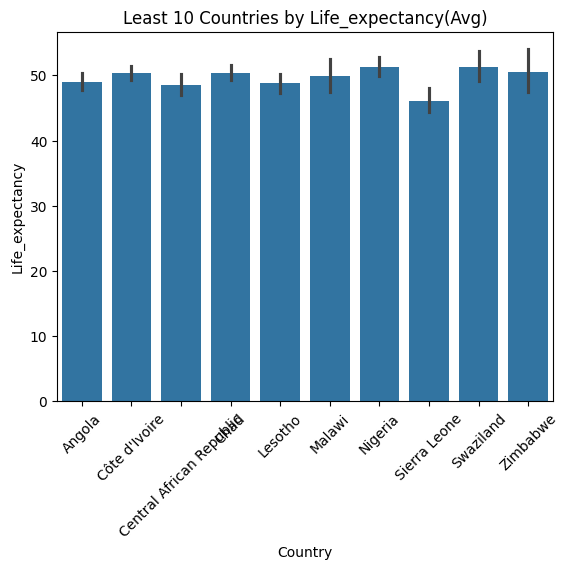

In [16]:
#To get the least countries by Life_expectancy
least10_Life_expectancy = df.groupby('Country')['Life_expectancy'].mean().sort_values(ascending=False).tail(10)
df_least10 = df[df['Country'].isin(least10_Life_expectancy.index)]

sns.barplot(x='Country', y='Life_expectancy', data=df_least10)
plt.title("Least 10 Countries by Life_expectancy(Avg)")
plt.xticks(rotation=45)
plt.show()

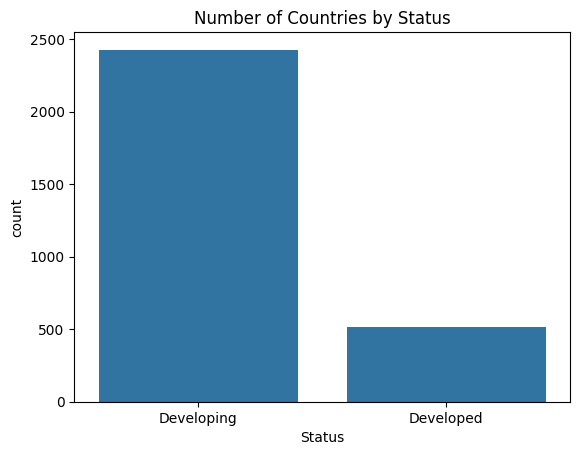

In [17]:
# Status (Developed vs Developing)
sns.countplot(x='Status', data=df)
plt.title("Number of Countries by Status")
plt.show()

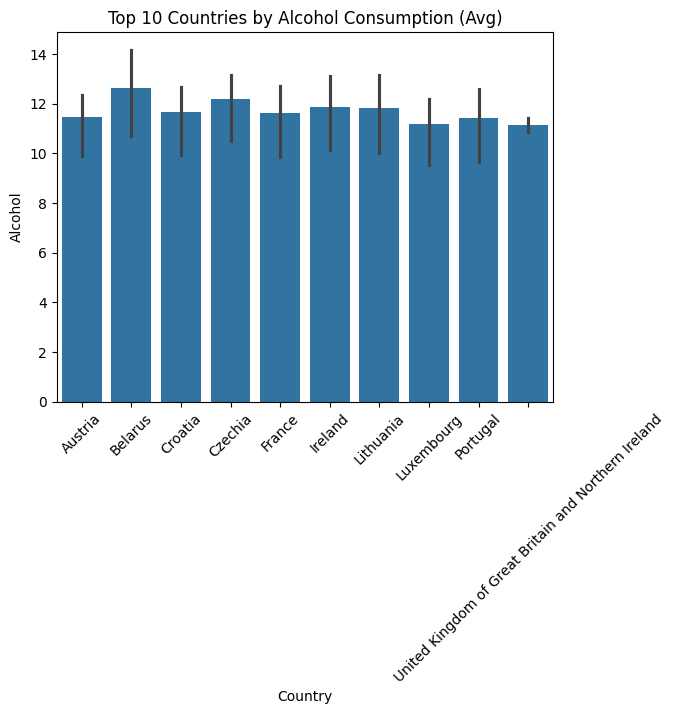

In [18]:
#To get the top countries by Alcohol consumption
top10_alcohol = df.groupby('Country')['Alcohol'].mean().sort_values(ascending=False).head(10)
df_top10 = df[df['Country'].isin(top10_alcohol.index)]

sns.barplot(x='Country', y='Alcohol', data=df_top10)
plt.title("Top 10 Countries by Alcohol Consumption (Avg)")
plt.xticks(rotation=45)
plt.show()


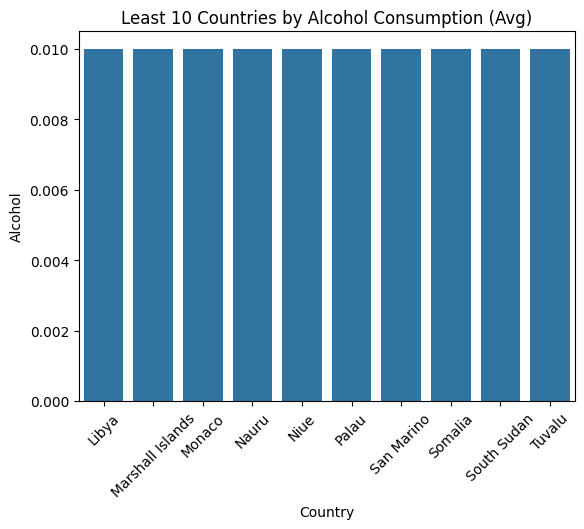

In [19]:
#To get the least countries by Alcohol consumption
least10_alcohol = df.groupby('Country')['Alcohol'].mean().sort_values(ascending=False).tail(10)
df_least10 = df[df['Country'].isin(least10_alcohol.index)]

sns.barplot(x='Country', y='Alcohol', data=df_least10)
plt.title("Least 10 Countries by Alcohol Consumption (Avg)")
plt.xticks(rotation=45)
plt.show()


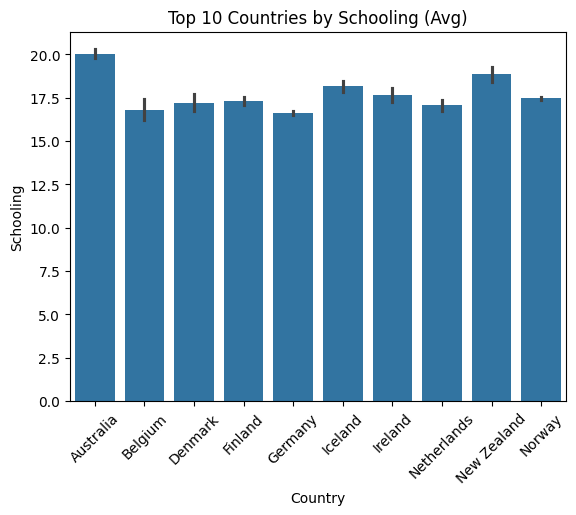

In [20]:
#To get the top countries by Schooling
top10_Schooling = df.groupby('Country')['Schooling'].mean().sort_values(ascending=False).head(10)
df_top10 = df[df['Country'].isin(top10_Schooling.index)]

sns.barplot(x='Country', y='Schooling', data=df_top10)
plt.title("Top 10 Countries by Schooling (Avg)")
plt.xticks(rotation=45)
plt.show()


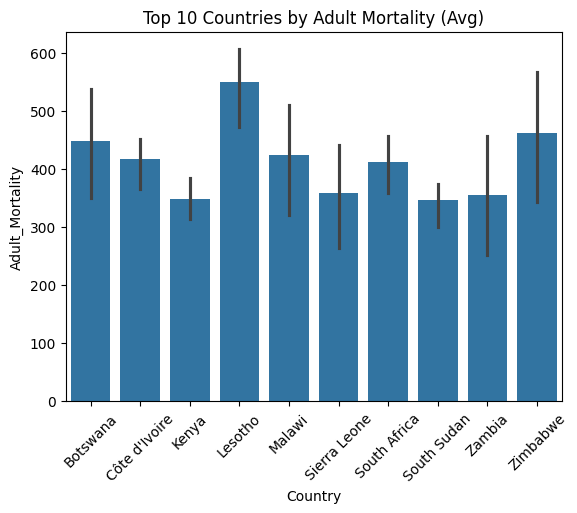

In [21]:
#To get the top countries by Adult Mortality
top10_Adult_Mortality = df.groupby('Country')['Adult_Mortality'].mean().sort_values(ascending=False).head(10)
df_top10 = df[df['Country'].isin(top10_Adult_Mortality.index)]

sns.barplot(x='Country', y='Adult_Mortality', data=df_top10)
plt.title("Top 10 Countries by Adult Mortality (Avg)")
plt.xticks(rotation=45)
plt.show()


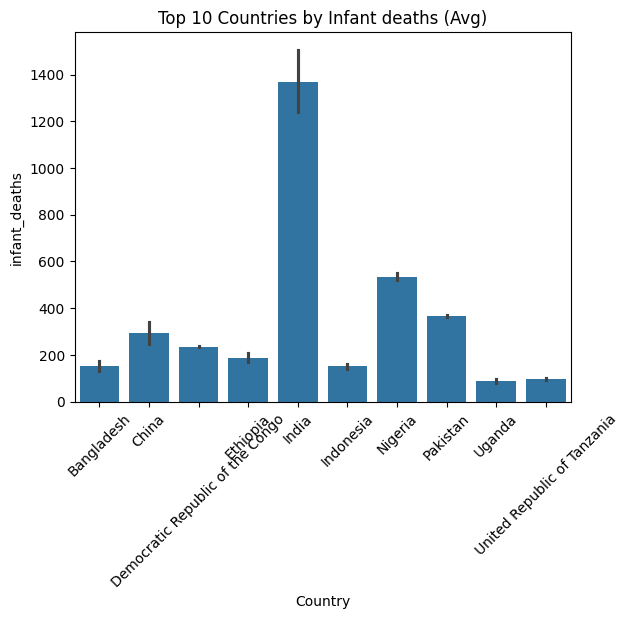

In [22]:
#To get the top countries by Infant deaths
top10_infant_deaths = df.groupby('Country')['infant_deaths'].mean().sort_values(ascending=False).head(10)
df_top10 = df[df['Country'].isin(top10_infant_deaths.index)]

sns.barplot(x='Country', y='infant_deaths', data=df_top10)
plt.title("Top 10 Countries by Infant deaths (Avg)")
plt.xticks(rotation=45)
plt.show()

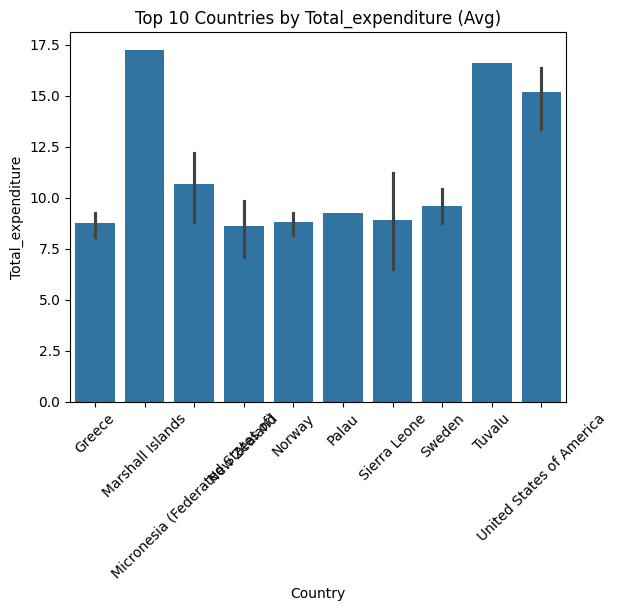

In [23]:
#To get the top countries by Total countries
top10_Total_expenditure = df.groupby('Country')['Total_expenditure'].mean().sort_values(ascending=False).head(10)
df_top10 = df[df['Country'].isin(top10_Total_expenditure.index)]

sns.barplot(x='Country', y='Total_expenditure', data=df_top10)
plt.title("Top 10 Countries by Total_expenditure (Avg)")
plt.xticks(rotation=45)
plt.show()

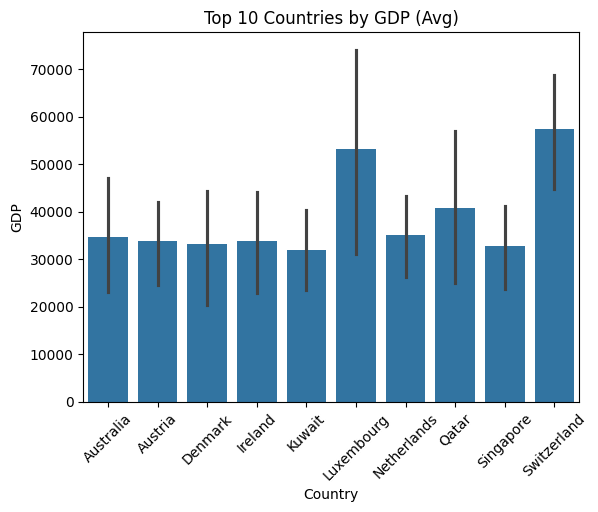

In [24]:
top10_GDP = df.groupby('Country')['GDP'].mean().sort_values(ascending=False).head(10)
df_top10 = df[df['Country'].isin(top10_GDP.index)]

sns.barplot(x='Country', y='GDP', data=df_top10)
plt.title("Top 10 Countries by GDP (Avg)")
plt.xticks(rotation=45)
plt.show()

**MULTIVARIATE ANALYSIS**

In [25]:
correlation = df.select_dtypes(include=['int64', 'float64']).corr()

In [26]:
correlation

,Year,Life_expectancy,Adult_Mortality,infant_deaths,Hepatitis_B,Polio,BMI,GDP,Schooling,Total_expenditure,Alcohol,under-five_deaths
Year,1.000000,0.171183,-0.083627,-0.037415,-0.020203,0.089941,0.108467,0.090481,0.203336,0.028280,-0.155874,-0.042937
Life_expectancy,0.171183,1.000000,-0.696043,-0.196830,0.147037,0.456296,0.544668,0.428324,0.709315,0.206949,0.368554,-0.222798
Adult_Mortality,-0.083627,-0.696043,1.000000,0.079620,-0.110453,-0.267695,-0.372908,-0.279320,-0.427291,-0.116409,-0.181667,0.094990
infant_deaths,-0.037415,-0.196830,0.079620,1.000000,-0.157669,-0.170924,-0.224597,-0.101048,-0.189125,-0.123241,-0.105467,0.996629
Hepatitis_B,-0.020203,0.147037,-0.110453,-0.157669,1.000000,0.333112,0.097904,0.084852,0.121049,0.057293,0.095270,-0.159232
Polio,0.089941,0.456296,-0.267695,-0.170924,0.333112,1.000000,0.277956,0.187205,0.368309,0.132096,0.200213,-0.188847
BMI,0.108467,0.544668,-0.372908,-0.224597,0.097904,0.277956,1.000000,0.267111,0.474209,0.221442,0.278081,-0.234476
GDP,0.090481,0.428324,-0.279320,-0.101048,0.084852,0.187205,0.267111,1.000000,0.425479,0.111480,0.302077,-0.104215
Schooling,0.203336,0.709315,-0.427291,-0.189125,0.121049,0.368309,0.474209,0.425479,1.000000,0.219536,0.483729,-0.204273
Total_expenditure,0.028280,0.206949,-0.116409,-0.123241,0.057293,0.132096,0.221442,0.111480,0.219536,1.000000,0.321953,-0.124833


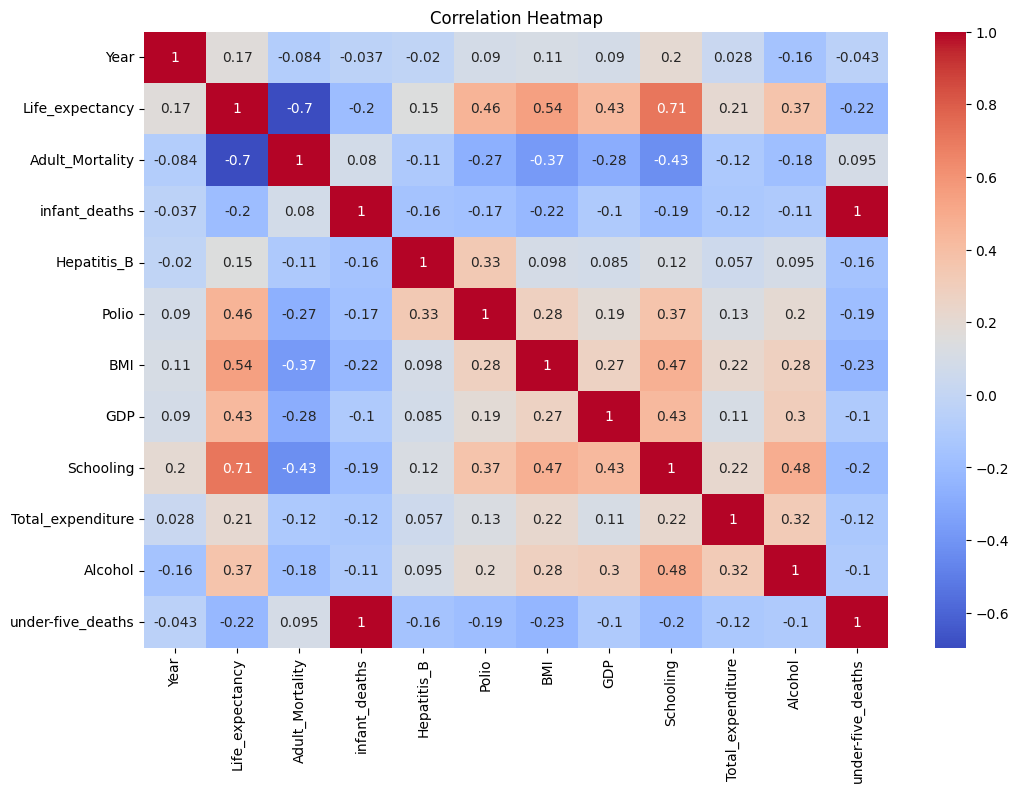

In [27]:
plt.figure(figsize=(12,8))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [28]:
selected_columns = ['GDP', 'Life_expectancy', 'Schooling', 'infant_deaths', 'Polio']
correlation_matrix = df[selected_columns].corr()

correlation_matrix

,GDP,Life_expectancy,Schooling,infant_deaths,Polio
GDP,1.000000,0.428324,0.425479,-0.101048,0.187205
Life_expectancy,0.428324,1.000000,0.709315,-0.196830,0.456296
Schooling,0.425479,0.709315,1.000000,-0.189125,0.368309
infant_deaths,-0.101048,-0.196830,-0.189125,1.000000,-0.170924
Polio,0.187205,0.456296,0.368309,-0.170924,1.000000


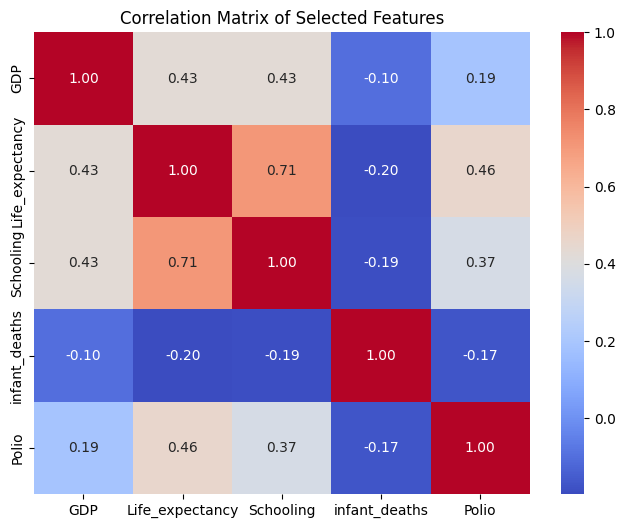

In [29]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Selected Features")
plt.show()

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


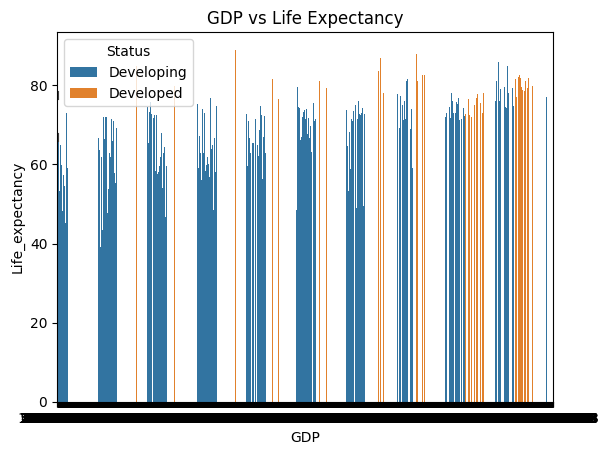

In [30]:
sns.barplot(x='GDP', y='Life_expectancy', hue='Status', data=df)
plt.title("GDP vs Life Expectancy")
plt.show()

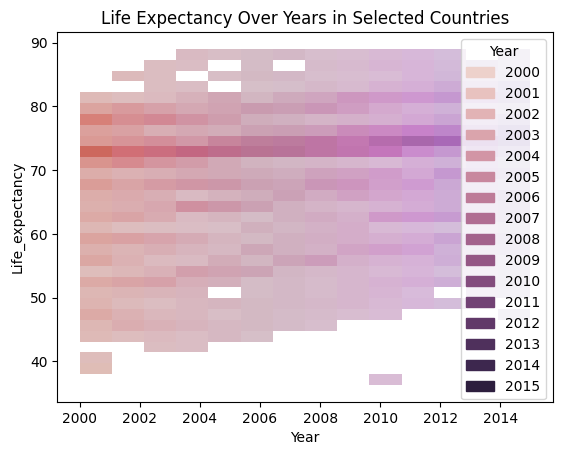

In [31]:
sns.histplot(x='Year', y='Life_expectancy', hue='Year', data=df)
plt.title("Life Expectancy Over Years in Selected Countries")
plt.show()

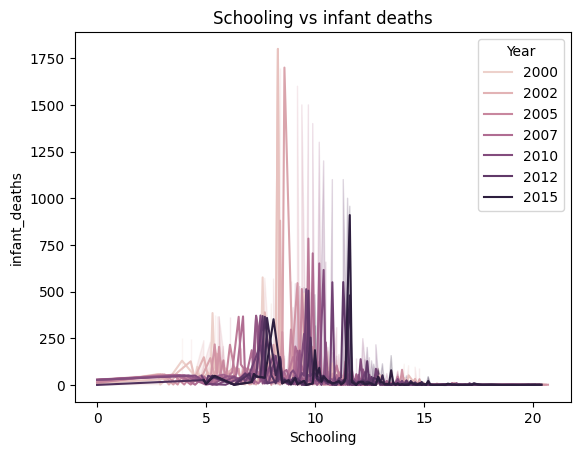

In [32]:
sns.lineplot(x='Schooling', y='infant_deaths', hue='Year', data=df)
plt.title("Schooling vs infant deaths")
plt.show()

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


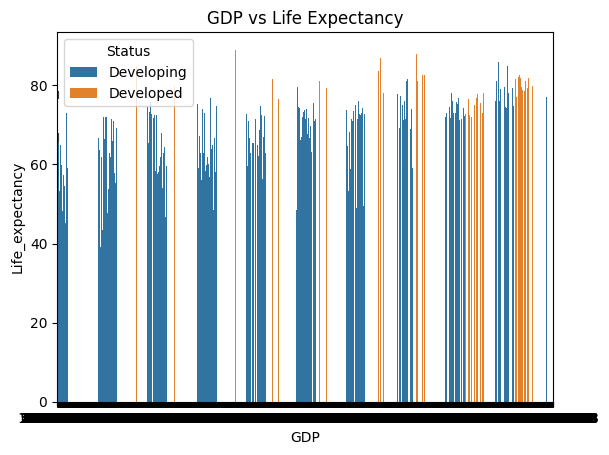

In [33]:
sns.barplot(x='GDP', y='Life_expectancy', hue='Status', data=df)
plt.title("GDP vs Life Expectancy")
plt.show()

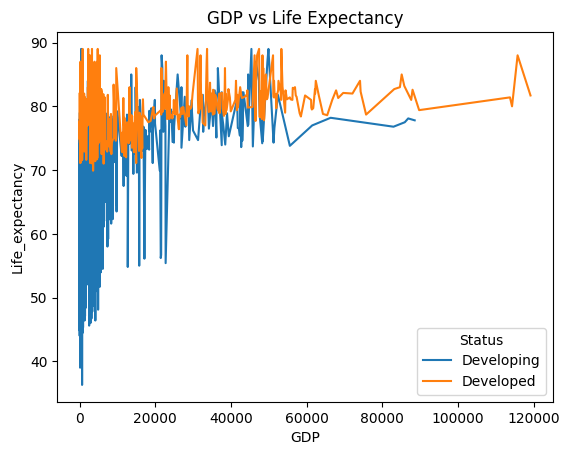

In [34]:
sns.lineplot(x='GDP', y='Life_expectancy', hue='Status', data= df)
plt.title("GDP vs Life Expectancy")
plt.show()

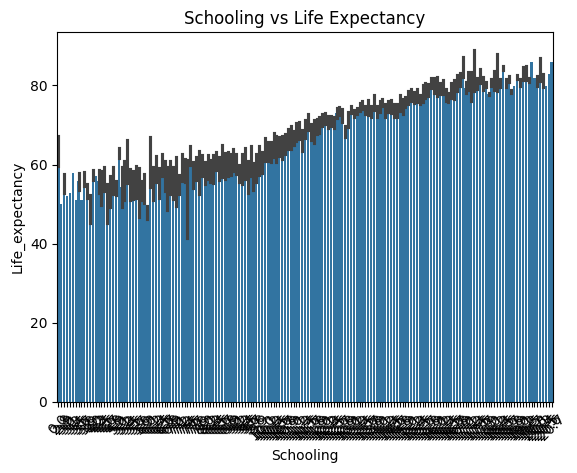

In [35]:
top10_under_five_deaths = df.groupby('Schooling')['Life_expectancy'].mean().sort_values(ascending=False).head(10)
df_top10 = df[df['Schooling'].isin(top10_under_five_deaths.index)]

sns.barplot(x='Schooling', y='Life_expectancy', data=df)
plt.title("Schooling vs Life Expectancy")
plt.xticks(rotation=45)
plt.show()

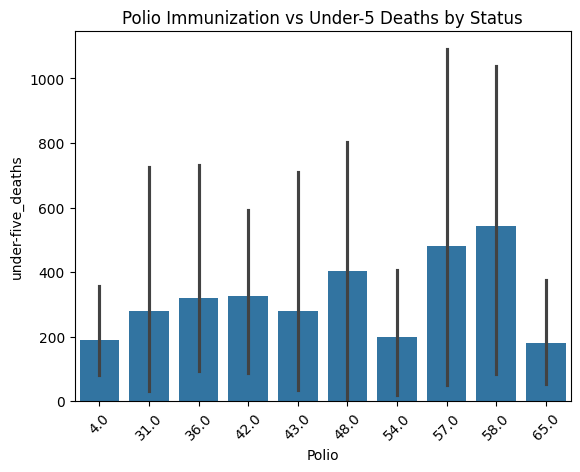

In [36]:
top10_under_five_deaths = df.groupby('Polio')['under-five_deaths'].mean().sort_values(ascending=False).head(10)
df_top10 = df[df['Polio'].isin(top10_under_five_deaths.index)]

sns.barplot(x='Polio', y='under-five_deaths', data=df_top10)
plt.title("Polio Immunization vs Under-5 Deaths by Status")
plt.xticks(rotation=45)
plt.show()

**Conclusion:**

While analyzing this dataset, I focused on columns like Country, Year,  Status, Life Expectancy, Adult Mortality, Infant Deaths, Hepatitis B, Polio, BMI, GDP, Schooling, Total Expenditure, Alcohol, and Under-Five Deaths.

From my analysis, I noticed that life expectancy isn't really influenced by the top 10 countries, but it’s quite different when looking at the bottom 10. Most of the countries with the lowest life expectancy are in Africa, which suggests that the continent still faces some major health and development challenges.

I also looked at the Status column and saw that there are more developing countries in the dataset than developed ones. When I analyzed alcohol consumption, I found that European countries consume more alcohol, with Belarus being the highest and Luxembourg the lowest among the top 10.

For schooling, Australia had the highest average years of schooling, and Germany had the lowest in the top 10. This shows that, in general, European and developed countries have better access to education compared to African nations.

In terms of adult mortality, Lesotho had the highest rate, and Kenya and South Sudan were also among the top 10. This again highlights the health issues faced by many African countries.

When I checked infant deaths, India had the highest number by a huge margin, followed by Nigeria, and then Uganda and Tanzania. Interestingly, Marshall Islands had the highest total health expenditure, but their schooling and life expectancy weren’t very high.

Lastly, Switzerland had the highest GDP, followed by Luxembourg, showing a strong link between wealth and better health or living conditions.

Overall, this analysis helped me understand how different health, economic, and social factors affect life expectancy and development across the world. It also made it clear how important education, income, and healthcare are to improving people’s lives especially in developing countries.

